In [1]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import pickle
import xgboost as xgb

In [2]:
# task 2

# Task 2 Extreme Gradient Boosting (XGboost)

### Loading data

In [3]:
from sklearn.metrics import classification_report
import pandas as pd
import math
import glob

dfs = []
for f in glob.glob("../data/SPI_*.csv.zip"):
    dfs.append(pd.read_csv(f))
SPI = pd.concat(dfs)

dfs = []
for f in glob.glob("../data/AOI_*.csv.zip"):
    dfs.append(pd.read_csv(f))
AOI = pd.concat(dfs)

/opt/anaconda3/envs/bigdatalab_cpu_202101/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3427: DtypeWarning: Columns (17) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [4]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [5]:
missing_values_table(SPI)

Your selected dataframe has 21 columns.
There are 7 columns that have missing values.


,Missing Values,% of Total Values
FigureID,1,0.0
Date,1,0.0
Time,1,0.0
OffsetX(%),1,0.0
OffsetY(%),1,0.0
PosX(mm),1,0.0
PosY(mm),1,0.0


In [6]:
SPI=SPI.dropna(subset=['FigureID'],axis=0)

### Separating training and validation

In [7]:
panel_ids=AOI['PanelID'].unique()

In [8]:
temp=[0 for i in range(len(panel_ids))]

In [9]:
panel_ids_train, panel_ids_test, y_train, y_test = train_test_split(panel_ids, 
                                                                    temp, test_size=0.33, random_state=42) # split the data as train (67%) and test (33%)

In [10]:
AOI_train=AOI[AOI['PanelID'].isin(panel_ids_train)].reset_index(drop=True)
AOI_test=AOI[AOI['PanelID'].isin(panel_ids_test)].reset_index(drop=True)

In [11]:
SPI_train=SPI[SPI['PanelID'].isin(panel_ids_train)].reset_index(drop=True)
SPI_test=SPI[SPI['PanelID'].isin(panel_ids_test)].reset_index(drop=True)

In [12]:
SPI_train['FigureID']=SPI_train['FigureID'].astype(int)

In [13]:
from prep_task2_aoi_approach_component import *

In [14]:
feature_matrix_t2_training=preprocessing_task2(SPI_train.copy(),AOI_train.copy())
feature_matrix_t2_test=preprocessing_task2(SPI_test.copy(),AOI_test.copy())

/home/phme/jtaco/data-challenge-phme/john_code/paperfinal_soluction_coments/prep_task2_aoi_approach_component.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ,'Misaligned':'7'})
/home/phme/jtaco/data-challenge-phme/john_code/paperfinal_soluction_coments/prep_task2_aoi_approach_component.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aoi_t2['AOILabel']=aoi_t2['AOILabel'].fillna('8')
/home/phme/jtaco/data-challenge-phme/john_code/paperfinal_soluction_coments/prep_task2_aoi_approach_component.py:16:

In [15]:
feature_matrix_t2_training.columns

Index(['PanelID', 'FigureID', 'ComponentID', 'Number_of_1', 'Number_of_2',
       'Number_of_3', 'Number_of_4', 'Number_of_5', 'Number_of_6',
       'Number_of_7', 'Number_of_8', 'AOILabel_count', 'AOILabel_nunique',
       'Component_type', 'Component_number'],
      dtype='object')

In [16]:
missing_values_table(feature_matrix_t2_training)

Your selected dataframe has 15 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


In [17]:
missing_values_table(feature_matrix_t2_test)

Your selected dataframe has 15 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


### Labeling data

In [18]:
dfs = []
for f in glob.glob("../data/AOI_*.csv.zip"):
    dfs.append(pd.read_csv(f))
AOI = pd.concat(dfs)

In [19]:
AOI=AOI[['PanelID','FigureID','ComponentID','OperatorLabel']]

In [20]:
AOI_unique=AOI.groupby(['PanelID','FigureID','ComponentID'])['OperatorLabel'].first().reset_index()

In [21]:
AOI_unique['OperatorLabel']=AOI_unique['OperatorLabel'].map({'Good':0,'Bad':1})

In [22]:
missing_values_table(AOI_unique)

Your selected dataframe has 4 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


In [23]:
AOI_unique

,PanelID,FigureID,ComponentID,OperatorLabel
0,25319088000520102844,3,C8,0
1,25319088000520102844,3,R2,0
2,25319088000520102844,3,TRB3,1
3,25319088000520102844,5,R2,0
4,25319088000520102844,6,BC1,0
...,...,...,...,...
27509,27219034900520102844,6,R21,0
27510,27219034900520102844,7,TRB1,0
27511,27219034900520102844,7,U3,0
27512,27219034900520102844,8,BC1,0


In [24]:
feature_matrix_t2_training=feature_matrix_t2_training.merge(AOI_unique,on=['PanelID','FigureID','ComponentID'],how='left')

In [25]:
feature_matrix_t2_test=feature_matrix_t2_test.merge(AOI_unique,on=['PanelID','FigureID','ComponentID'],how='left')

In [26]:
feature_matrix_t2_training.shape

(18413, 16)

In [27]:
feature_matrix_t2_test.shape

(9101, 16)

In [28]:
missing_values_table(feature_matrix_t2_training)

Your selected dataframe has 16 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


In [29]:
missing_values_table(feature_matrix_t2_test)

Your selected dataframe has 16 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


In [30]:
X_train=feature_matrix_t2_training.drop(['PanelID','FigureID','ComponentID','OperatorLabel'],axis=1)
X_test=feature_matrix_t2_test.drop(['PanelID','FigureID','ComponentID','OperatorLabel'],axis=1)

In [31]:
X_train.shape

(18413, 12)

In [32]:
y_train=feature_matrix_t2_training['OperatorLabel'].copy()
y_test=feature_matrix_t2_test['OperatorLabel'].copy()

In [33]:
scores=pd.DataFrame()

### Training

In [34]:
%%time
from sklearn.model_selection import StratifiedKFold

y_train_xgb_prob=[0 for j in range(X_train.shape[0])]
y_test_xgb_prob=[0 for j in range(X_test.shape[0])]
feature_importances_xgb=[0 for j in range(len(X_train.columns))]
i=1
X_train=X_train.values
y_train=y_train.values
X_test=X_test.values
y_test=y_test.values
kfold=StratifiedKFold(n_splits=5,shuffle=True,random_state=2022)

for train_index, test_index in kfold.split(X_train, y_train):
    
    x_tr, x_val = X_train[train_index], X_train[test_index]
    y_tr, y_val = y_train[train_index], y_train[test_index]
    
    model_xgb = xgb.XGBClassifier( 
        n_estimators=5000,
        max_depth=4, 
        learning_rate=0.2, 
        subsample=0.8,
        colsample_bytree=0.4, 
        missing=-1, 
        eval_metric='auc',
        #nthread=4,
        #tree_method='hist'
     )
    h = model_xgb.fit(x_tr, y_tr, 
        eval_set=[(x_tr,y_tr),(x_val,y_val)],
        verbose=50, early_stopping_rounds=100)
    
    #file_name = "xgb_task2_aoiapproach_comp_cv_{}_alldata.pkl".format(i)
    #pickle.dump(model_xgb, open(file_name, "wb"))
    
    feature_importances_xgb+=model_xgb.feature_importances_*1000
    
    y_train_xgb_prob+=model_xgb.predict_proba(X_train)[:,1]
    y_test_xgb_prob+=model_xgb.predict_proba(X_test)[:,1]

    i=i+1

y_train_xgb_prob /= 5.
y_test_xgb_prob /= 5.
feature_importances_xgb /= 5.

[0]	validation_0-auc:0.68434	validation_1-auc:0.70455
Multiple eval metrics have been passed: 'validation_1-auc' will be used for early stopping.

Will train until validation_1-auc hasn't improved in 100 rounds.
[50]	validation_0-auc:0.858998	validation_1-auc:0.843945
[100]	validation_0-auc:0.871561	validation_1-auc:0.834615
Stopping. Best iteration:
[23]	validation_0-auc:0.846169	validation_1-auc:0.861673

[0]	validation_0-auc:0.60621	validation_1-auc:0.575174
Multiple eval metrics have been passed: 'validation_1-auc' will be used for early stopping.

Will train until validation_1-auc hasn't improved in 100 rounds.
[50]	validation_0-auc:0.871404	validation_1-auc:0.819946
[100]	validation_0-auc:0.878535	validation_1-auc:0.809745
[150]	validation_0-auc:0.884712	validation_1-auc:0.80125
[200]	validation_0-auc:0.888004	validation_1-auc:0.820168
Stopping. Best iteration:
[129]	validation_0-auc:0.881523	validation_1-auc:0.822771

[0]	validation_0-auc:0.690614	validation_1-auc:0.679626
Multi

In [35]:
import numpy as np
from sklearn import metrics

In [36]:
fpr_train, tpr_train, thresholds_train = metrics.roc_curve(y_train, y_train_xgb_prob)
print('auc_train',metrics.auc(fpr_train, tpr_train))

auc_train 0.8667354873232163


In [37]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_test_xgb_prob)
print('auc_test',metrics.auc(fpr, tpr))

auc_test 0.827399232063079



Bad key "text.kerning_factor" on line 4 in
/opt/anaconda3/envs/bigdatalab_cpu_202101/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test_patch.mplstyle.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.2/matplotlibrc.template
or from the matplotlib source distribution


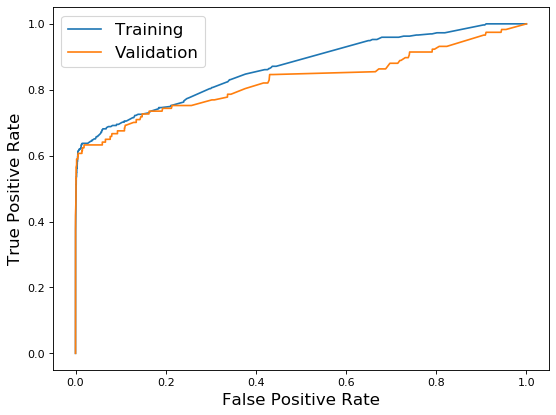

In [38]:
#create ROC curve
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
figure(figsize=(8, 6), dpi=80)
plt.plot(fpr_train,tpr_train)
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate',fontsize=15)
plt.xlabel('False Positive Rate',fontsize=15)
plt.legend(['Training','Validation'],fontsize=15)
#plt.savefig("roc_curve_aoi.png")
#plt.rcParams.update({'font.size': 30})
plt.rcParams.update({'font.size':15})
plt.show()

In [39]:
f1s=[]

for threshold in thresholds:
    y_train_xgb=(y_train_xgb_prob>threshold)*1
    y_test_xgb=(y_test_xgb_prob>threshold)*1
    f1=f1_score(y_test, y_test_xgb)
    f1s.append(f1)
f1s=np.array(f1s)
ix=np.argmax(f1s)
opt_threshold=thresholds[ix]

In [40]:
opt_threshold

0.17750492990016936

In [41]:
y_train_xgb=(y_train_xgb_prob>opt_threshold)*1
y_test_xgb=(y_test_xgb_prob>opt_threshold)*1

In [42]:
acc=accuracy_score(y_train, y_train_xgb)
f1=f1_score(y_train, y_train_xgb)
recall=recall_score(y_train, y_train_xgb)
precision=precision_score(y_train, y_train_xgb)

print('xgb accuracy train',acc)
print('xgb f1 train',f1)
print('xgb recall train',recall)
print('xgb precision train',precision)

xgb accuracy train 0.991038939879433
xgb f1 train 0.6555323590814196
xgb recall train 0.5322033898305085
xgb precision train 0.8532608695652174


In [43]:
acc=accuracy_score(y_test, y_test_xgb)
f1=f1_score(y_test, y_test_xgb)
recall=recall_score(y_test, y_test_xgb)
precision=precision_score(y_test, y_test_xgb)

print('xgb accuracy validation',acc)
print('xgb f1 validation',f1)
print('xgb recall validation',recall)
print('xgb precision validation',precision)

xgb accuracy validation 0.9930776837710141
xgb f1 validation 0.676923076923077
xgb recall validation 0.5641025641025641
xgb precision validation 0.8461538461538461


### Feature importances

In [44]:
feature_importance_xgb=pd.DataFrame()
feature_importance_xgb['Value']=feature_importances_xgb/1000
feature_importance_xgb['Feature']=feature_matrix_t2_training.drop(['PanelID','FigureID','ComponentID','OperatorLabel'],axis=1).columns
feature_importance_xgb.sort_values(by='Value',ascending=False,inplace=True)

In [45]:
# Renaming the labels from numbers to their original name
feature_importance_xgb['Feature']=feature_importance_xgb['Feature'].map({'Component_number':'Component_number','AOILabel_count':'AOILabel_count','Component_type':'Component_type',
                                       'AOILabel_nunique':'AOILabel_nunique',
                                       'Number_of_4':'Number_of_Translated',
                                    'Number_of_3':'Number_of_Coplanarity',
                                      'Number_of_1':'Number_of_Soldered','Number_of_8':'Number_of_Others',
                                      'Number_of_7':'Number_of_Misaligned','Number_of_6':'Number_of_Size',
                                      'Number_of_2':'Number_of_UnSoldered','Number_of_5':'Number_of_LeanSoldering'})

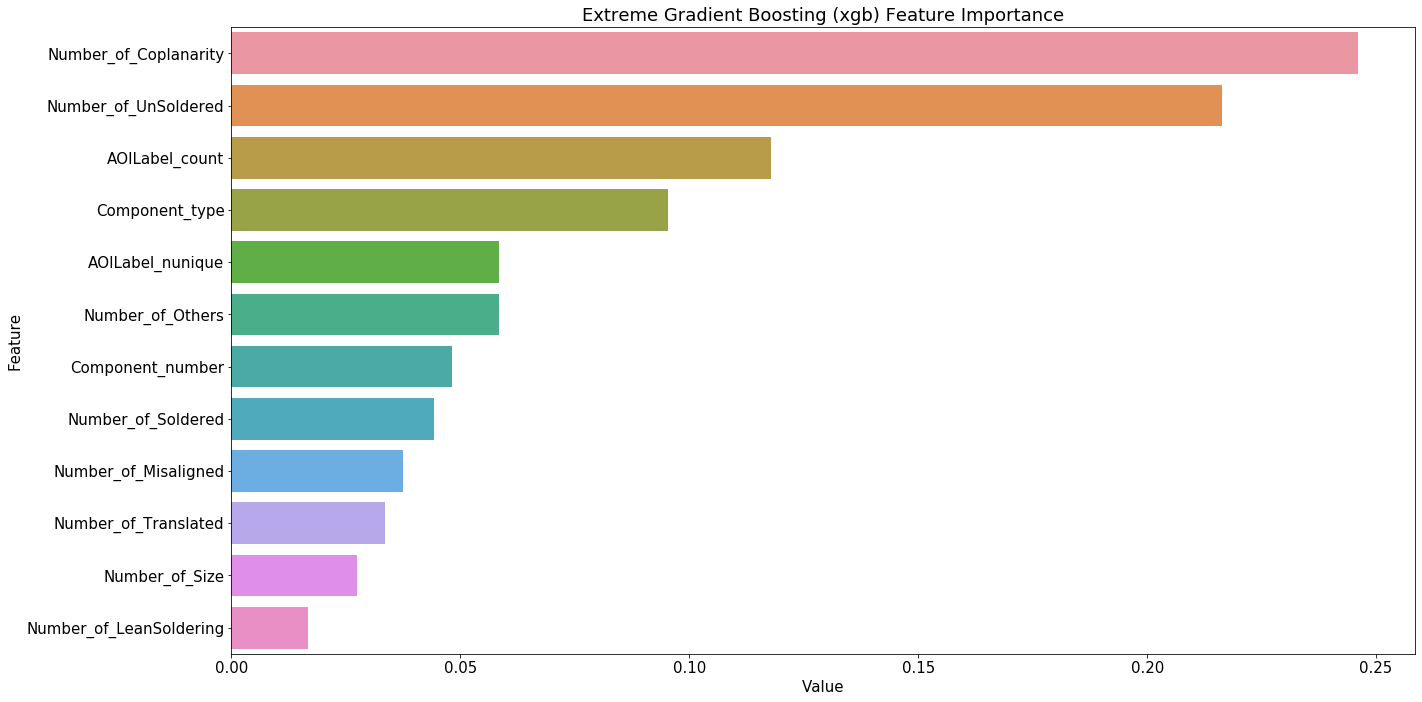

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

plt.figure(figsize=(20, 10))
sns.barplot(x="Value", y="Feature",data=feature_importance_xgb[0:50])
plt.title('Extreme Gradient Boosting (xgb) Feature Importance')
plt.tight_layout()
plt.show()